# Load Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# !pip install openpyxl

# Data Extraction

In [3]:
df = pd.read_excel("First_Dataset.xlsx")
df.head()

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,F,19.0,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5
1,1002,Sina,M,53.0,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3
2,1003,Parsa,F,31.0,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,F,58.0,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4
4,1005,Kimia,M,28.0,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4


In [4]:
df.describe()

,customer_id,age,purchase_count,avg_order_value,total_spending,last_purchase_days,returned_items,satisfaction_score
count,61.000000,60.000000,61.000000,61.000000,60.000000,61.000000,61.000000,61.00000
mean,1030.229508,45.200000,17.606557,211.435738,3749.667333,196.934426,4.196721,3.00000
std,17.446483,19.167239,10.214824,130.113726,4262.248522,97.892436,2.663454,1.42595
min,1001.000000,19.000000,0.000000,27.630000,0.000000,3.000000,0.000000,1.00000
25%,1015.000000,31.750000,11.000000,108.190000,1167.035000,132.000000,2.000000,2.00000
50%,1030.000000,45.000000,17.000000,161.330000,2188.865000,201.000000,4.000000,3.00000
75%,1045.000000,58.000000,26.000000,323.320000,4692.150000,273.000000,7.000000,4.00000
max,1060.000000,145.000000,35.000000,449.810000,25000.000000,365.000000,8.000000,5.00000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         61 non-null     int64  
 1   first_name          61 non-null     object 
 2   gender              61 non-null     object 
 3   age                 60 non-null     float64
 4   city                61 non-null     object 
 5   province            61 non-null     object 
 6   signup_date         61 non-null     object 
 7   membership_tier     61 non-null     object 
 8   purchase_count      61 non-null     int64  
 9   avg_order_value     61 non-null     float64
 10  total_spending      60 non-null     float64
 11  last_purchase_days  61 non-null     int64  
 12  payment_method      61 non-null     object 
 13  device              61 non-null     object 
 14  discount_used       61 non-null     object 
 15  returned_items      61 non-null     int64  
 16  satisfacti

In [6]:
print(f'Rows: {df.shape[0]}\nColumns: {df.shape[1]}')

Rows: 61
Columns: 17


# Preprocessing

In [7]:
df[df.duplicated()]

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
60,1014,Reza,M,35.0,Tabriz,East Azerbaijan,2022-08-26,VIP,31,108.19,3353.89,97,Card,Android,No,5,4


In [8]:
df.loc[df['customer_id'] == 1014]

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
13,1014,Reza,M,35.0,Tabriz,East Azerbaijan,2022-08-26,VIP,31,108.19,3353.89,97,Card,Android,No,5,4
60,1014,Reza,M,35.0,Tabriz,East Azerbaijan,2022-08-26,VIP,31,108.19,3353.89,97,Card,Android,No,5,4


In [9]:
df.duplicated().sum()

1

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.isna().sum()

customer_id           0
first_name            0
gender                0
age                   1
city                  0
province              0
signup_date           0
membership_tier       0
purchase_count        0
avg_order_value       0
total_spending        1
last_purchase_days    0
payment_method        0
device                0
discount_used         0
returned_items        0
satisfaction_score    0
dtype: int64

In [12]:
df[df["total_spending"].isna()]

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
39,1040,Amir,F,65.0,Tehran,Tehran,2021-11-02,Bronze,34,37.66,NaN,126,Card,Android,Yes,3,2


In [13]:
total_spending_na = df["total_spending"].isna()
df.loc[total_spending_na, "total_spending"] = (df["purchase_count"] * df["avg_order_value"]).round(2)

In [14]:
df.dropna(inplace=True)

In [15]:
df.dtypes

customer_id             int64
first_name             object
gender                 object
age                   float64
city                   object
province               object
signup_date            object
membership_tier        object
purchase_count          int64
avg_order_value       float64
total_spending        float64
last_purchase_days      int64
payment_method         object
device                 object
discount_used          object
returned_items          int64
satisfaction_score      int64
dtype: object

In [16]:
cols = ['age', 'purchase_count', 'returned_items', 'satisfaction_score']
for i in cols:
    print(f'{i}\n{df[i].unique().tolist()}')

age
[19.0, 53.0, 31.0, 58.0, 28.0, 43.0, 23.0, 61.0, 145.0, 41.0, 51.0, 39.0, 35.0, 47.0, 45.0, 49.0, 30.0, 22.0, 50.0, 60.0, 37.0, 25.0, 34.0, 63.0, 26.0, 42.0, 65.0, 64.0, 54.0, 32.0, 48.0, 59.0, 62.0, 57.0]
purchase_count
[17, 12, 21, 23, 35, 29, 3, 34, 19, 27, 1, 31, 11, 30, 18, 4, 16, 6, 0, 2, 14, 26, 15, 24, 9, 7, 33, 13, 5, 10]
returned_items
[3, 5, 6, 4, 7, 2, 8, 1, 0]
satisfaction_score
[5, 3, 1, 4, 2]


In [17]:
df = df.astype({'age': 'Int16', 'purchase_count': 'Int8', 'returned_items': 'Int8', 'satisfaction_score': 'Int8'})

In [18]:
df.dtypes

customer_id             int64
first_name             object
gender                 object
age                     Int16
city                   object
province               object
signup_date            object
membership_tier        object
purchase_count           Int8
avg_order_value       float64
total_spending        float64
last_purchase_days      int64
payment_method         object
device                 object
discount_used          object
returned_items           Int8
satisfaction_score       Int8
dtype: object

In [19]:
print(df["signup_date"].dtype)

object


In [20]:
df["signup_date"] = pd.to_datetime(df["signup_date"])

### Handling Outliers in the age Column
#### Detected an invalid value (age = 145), likely an entry error. Imputing this outlier with the median age to maintain distribution integrity.

In [21]:
print(df["age"].unique())
print(f'min: {df["age"].min()}')
print(f'max: {df["age"].max()}')

<IntegerArray>
[ 19,  53,  31,  58,  28,  43,  23,  61, 145,  41,  51,  39,  35,  47,  45,
  49,  30,  22,  50,  60,  37,  25,  34,  63,  26,  42,  65,  64,  54,  32,
  48,  59,  62,  57]
Length: 34, dtype: Int16
min: 19
max: 145


In [22]:
df[df["age"] >= 80]

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
9,1010,Arash,F,145,Karaj,Alborz,2022-06-25,Silver,19,381.13,7241.47,276,Online Wallet,Android,No,7,1


In [23]:
df["age"].median()

45.0

In [24]:
df["age"] = df["age"].replace(145,45)

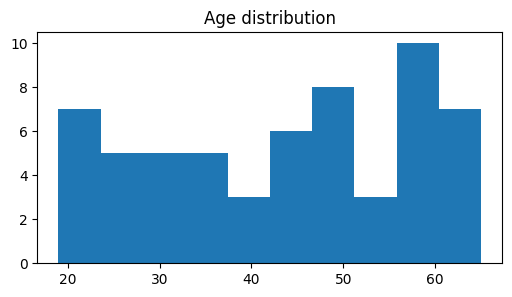

In [25]:
plt.figure(figsize=(6,3))
plt.hist(df["age"])
plt.title("Age distribution")
plt.show()

### How the customer didn't purches but membership is Gold!
#### the last purches is 298 days age, returnd 2 items wihout buying anything

In [26]:
df["purchase_count"].unique()

<IntegerArray>
[17, 12, 21, 23, 35, 29,  3, 34, 19, 27,  1, 31, 11, 30, 18,  4, 16,  6,  0,
  2, 14, 26, 15, 24,  9,  7, 33, 13,  5, 10]
Length: 30, dtype: Int8

In [27]:
df.loc[df["purchase_count"] == 0]

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
23,1024,Sina,F,53,Ahvaz,Khuzestan,2025-01-27,Gold,0,63.67,0.0,298,Online Wallet,Android,No,2,1


In [28]:
df = df[df["purchase_count"] >= 1]

#### returned items must be smaller or equal to purchase_count!

In [29]:
anomaly = (df["returned_items"] > df["purchase_count"]).sum()
print(anomaly)

5


In [30]:
df.loc[df["returned_items"] > df["purchase_count"]]

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
7,1008,Reza,F,23,Rasht,Gilan,2024-10-03,VIP,3,389.58,1168.74,195,Online Wallet,iPhone,No,8,1
14,1015,Kimia,F,47,Ahvaz,Khuzestan,2021-07-24,Gold,3,307.91,923.73,55,Card,Android,Yes,8,4
28,1029,Ali,F,34,Tabriz,East Azerbaijan,2023-07-03,Gold,2,323.32,646.64,319,Cash,Web,Yes,4,5
36,1037,Zahra,M,42,Ahvaz,Khuzestan,2024-01-12,Gold,1,387.68,387.68,199,Cash,Web,Yes,7,2
55,1056,Kimia,M,61,Tabriz,East Azerbaijan,2025-01-25,Silver,1,449.81,449.81,240,Online Wallet,Web,No,4,2


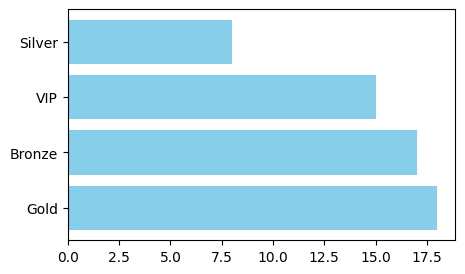

In [31]:
m = df["membership_tier"].value_counts()
plt.figure(figsize=(5,3))
plt.barh(m.index , m, color="skyblue")
plt.show()

In [32]:
df["device"].unique()

array(['Android', 'Web', 'iPhone'], dtype=object)

### Finding outliers in df["total_spending"]
#### Using plt.boxplot
#### df["customer_id"] == 1030 has invalid value

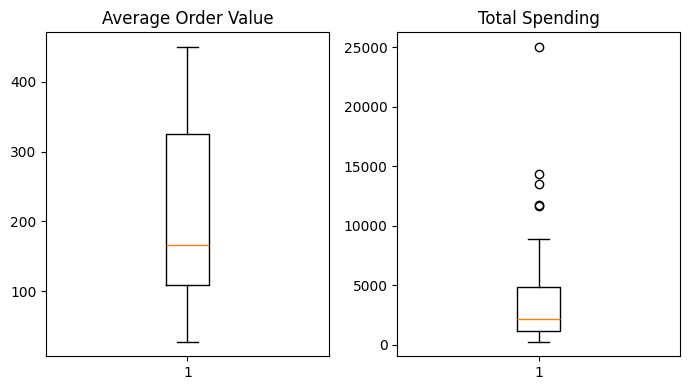

In [33]:
plt.figure(figsize=(7,4))
plt.subplot(1,2,1)
plt.boxplot(df["avg_order_value"])
plt.title("Average Order Value")
plt.subplot(1,2,2)
plt.boxplot(df["total_spending"])
plt.title("Total Spending")
plt.tight_layout()
plt.show()

In [34]:
 df.loc[df["total_spending"] > 10000]

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
8,1009,Kimia,M,61,Karaj,Alborz,2021-05-14,Silver,34,341.63,11615.42,232,Card,Web,No,8,2
11,1012,Arash,F,51,Mashhad,Khorasan,2023-07-22,Gold,27,434.50,11731.50,224,Online Wallet,iPhone,Yes,3,2
29,1030,Sina,M,60,Mashhad,Khorasan,2025-03-07,VIP,26,156.89,25000.00,340,Cash,Web,Yes,4,4
43,1044,Mina,M,64,Shiraz,Fars,2024-07-27,Gold,33,434.98,14354.34,165,Card,Android,No,7,2
56,1057,Maryam,M,58,Ahvaz,Khuzestan,2024-06-11,Bronze,31,436.54,13532.74,82,Cash,iPhone,No,4,4


In [35]:
mask = df["customer_id"] == 1030
df.loc[mask, "total_spending"] = (df["purchase_count"] * df["avg_order_value"]).round(2)

In [36]:
l = df.loc[df["customer_id"] == 1030]
l

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
29,1030,Sina,M,60,Mashhad,Khorasan,2025-03-07,VIP,26,156.89,4079.14,340,Cash,Web,Yes,4,4


### Checking other total spending

In [37]:
n = (df["purchase_count"] * df["avg_order_value"]).round(2)
mismatch = df[n != df["total_spending"]]
mismatch

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score


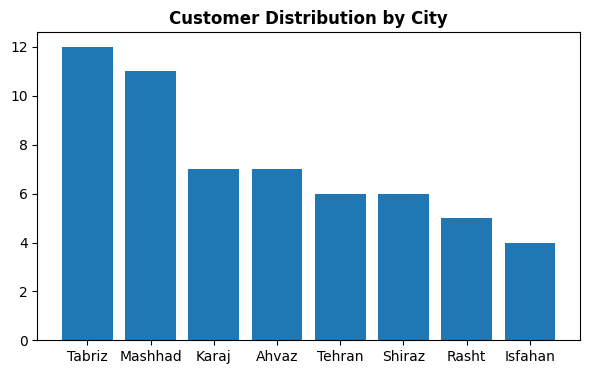

In [38]:
plt.figure(figsize=(7,4))
c = df["city"].value_counts()
plt.bar(c.index, c)
plt.title("Customer Distribution by City", fontweight="bold")
plt.show()

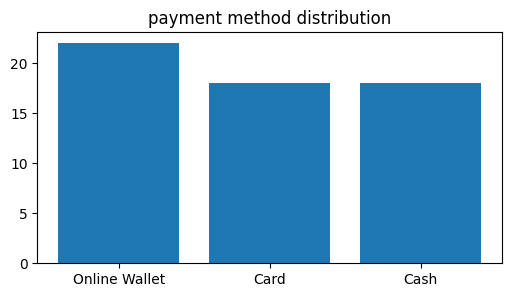

In [39]:
plt.figure(figsize=(6,3))
p = df["payment_method"].value_counts()
plt.title("payment method distribution")
plt.bar(p.index, p)
plt.show()

In [40]:
df["discount_used"] = df["discount_used"].map({"Yes":1, "No":0})

In [41]:
df["city"].unique()

array(['Karaj', 'Tehran', 'Shiraz', 'Mashhad', 'Isfahan', 'Rasht',
       'Tabriz', 'Ahvaz'], dtype=object)

In [42]:
df["province"].unique()

array(['Alborz', 'Tehran', 'Fars', 'Khorasan', 'Isfahan', 'Gilan',
       'East Azerbaijan', 'Khuzestan'], dtype=object)

In [43]:
df["satisfaction_score"].unique()

<IntegerArray>
[5, 3, 1, 4, 2]
Length: 5, dtype: Int8

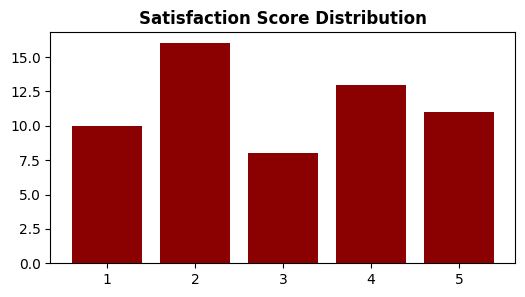

In [44]:
plt.figure(figsize=(6,3))
s = df["satisfaction_score"].value_counts()
plt.bar(s.index, s, color="darkred")
plt.title("Satisfaction Score Distribution", fontweight="bold")
plt.show()

In [45]:
top_customers = df.sort_values(by="total_spending", ascending=False).head(10)
top_customers

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
43,1044,Mina,M,64,Shiraz,Fars,2024-07-27,Gold,33,434.98,14354.34,165,Card,Android,0,7,2
56,1057,Maryam,M,58,Ahvaz,Khuzestan,2024-06-11,Bronze,31,436.54,13532.74,82,Cash,iPhone,0,4,4
11,1012,Arash,F,51,Mashhad,Khorasan,2023-07-22,Gold,27,434.50,11731.50,224,Online Wallet,iPhone,1,3,2
8,1009,Kimia,M,61,Karaj,Alborz,2021-05-14,Silver,34,341.63,11615.42,232,Card,Web,0,8,2
58,1059,Ali,F,57,Isfahan,Isfahan,2023-09-05,Gold,31,287.05,8898.55,224,Online Wallet,iPhone,1,0,5
9,1010,Arash,F,45,Karaj,Alborz,2022-06-25,Silver,19,381.13,7241.47,276,Online Wallet,Android,0,7,1
49,1050,Reza,F,48,Mashhad,Khorasan,2023-08-04,Bronze,30,206.60,6198.00,205,Cash,Android,1,2,2
3,1004,Sina,F,58,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,0,4,4
54,1055,Mina,M,62,Rasht,Gilan,2024-02-20,Bronze,19,319.38,6068.22,221,Online Wallet,iPhone,0,0,1
34,1035,Arash,M,58,Tabriz,East Azerbaijan,2022-05-15,Bronze,17,348.13,5918.21,365,Cash,Android,0,5,3


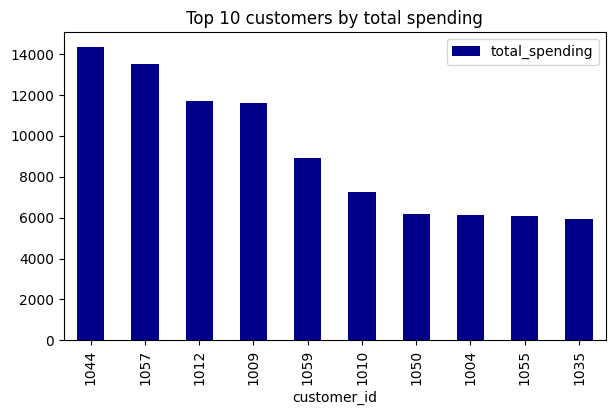

In [46]:
top_customers.plot(kind='bar', x='customer_id', y='total_spending', figsize=(7, 4), color='darkblue')
plt.title("Top 10 customers by total spending")
plt.show()

In [47]:
df.to_csv("cleaned_data.csv", index=False)